## Exploratory Data Analysis

This analysis focuses on understanding customer behavior, spending patterns, and potential segmentation.

Key goals:
- Identify high-value customers
- Understand drivers of spending
- Explore customer segments for business insights

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="talk")

## Load Data

In [72]:
#Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,"58,138.00",0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,"46,344.00",1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,"71,613.00",0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,"26,646.00",1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,"58,293.00",1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## Feature Engineering
The following features are added for improving interpretability:
1. Total_Spending: total product spending
2. Total_Purchasing: total number of purchases for all channels
3. Children: total number of dependents
4. Customer_Tenure: number of days since customer enrollment
5. Avg_Spending_Per_Purchase: spending efficiency proxy

In [73]:
spending_cols = [
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds'
]

df['Total_Spending'] = df[spending_cols].sum(axis=1)
df['Total_Purchasing'] = df[
    ['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases']
].sum(axis=1)

df['Children'] = df['Kidhome'] + df['Teenhome']

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
assert df['Dt_Customer'].notna().all(), 'Data conversion failed'
df['Customer_Tenure'] = (pd.Timestamp.now() - df['Dt_Customer']).dt.days

df['Avg_Spending_Per_Purchase'] = df['Total_Spending'] / (df['Total_Purchasing'] + 1)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchasing,Children,Customer_Tenure,Avg_Spending_Per_Purchase
0,5524,1957,Graduation,Single,"58,138.00",0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,1617,22,0,4972,70.30
1,2174,1954,Graduation,Single,"46,344.00",1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,27,4,2,4422,5.40
2,4141,1965,Graduation,Together,"71,613.00",0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,776,20,0,4621,36.95
3,6182,1984,Graduation,Together,"26,646.00",1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,53,6,1,4448,7.57
4,5324,1981,PhD,Married,"58,293.00",1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,422,14,1,4470,28.13


## Helper Functions

In [74]:
def remove_iqr_outliers(dataframe, column, whisker_width=1.5):
    """Return dataframe filtered by IQR boundaries for a given numeric column."""
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - whisker_width * iqr
    upper = q3 + whisker_width * iqr
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]


def plot_histogram(dataframe, column, bins=30):
    plt.figure(figsize=(10, 5))
    sns.histplot(data=dataframe, x=column, bins=bins, kde=True)
    plt.title(f"{column} Distribution")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_scatter(dataframe, x, y):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=dataframe, x=x, y=y, alpha=0.7)
    plt.title(f"{y} vs {x}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

## Univariate Analysis

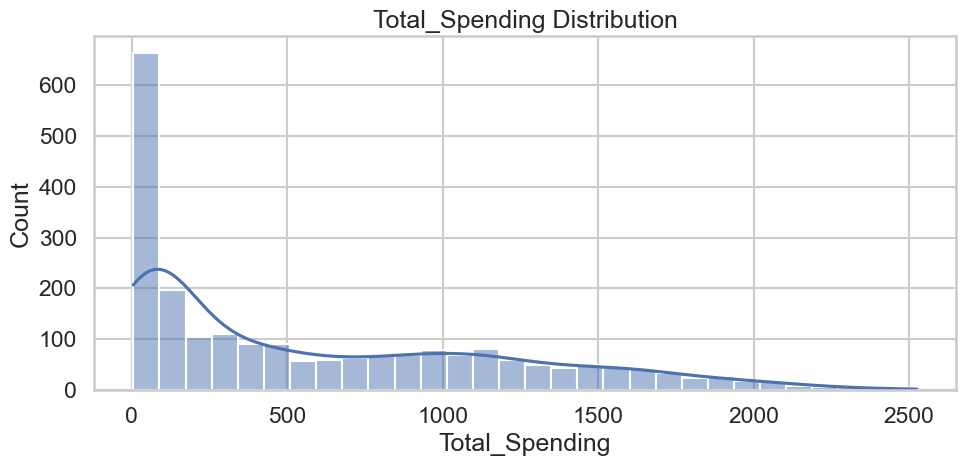

In [75]:
plot_histogram(df, "Total_Spending")

**Insight**

Total Spending is typically right-skewed, indicating that a small portion of customers contribute to a large share of revenue.

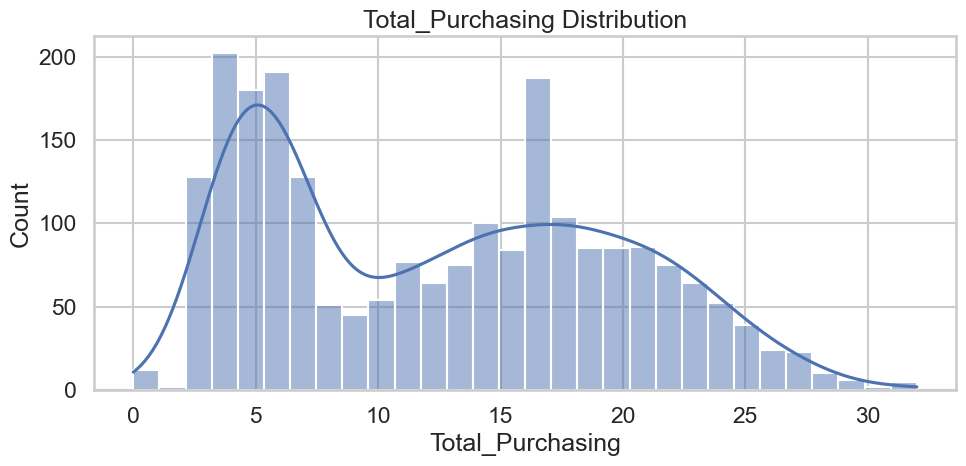

In [ ]:
plot_histogram(df, "Income")

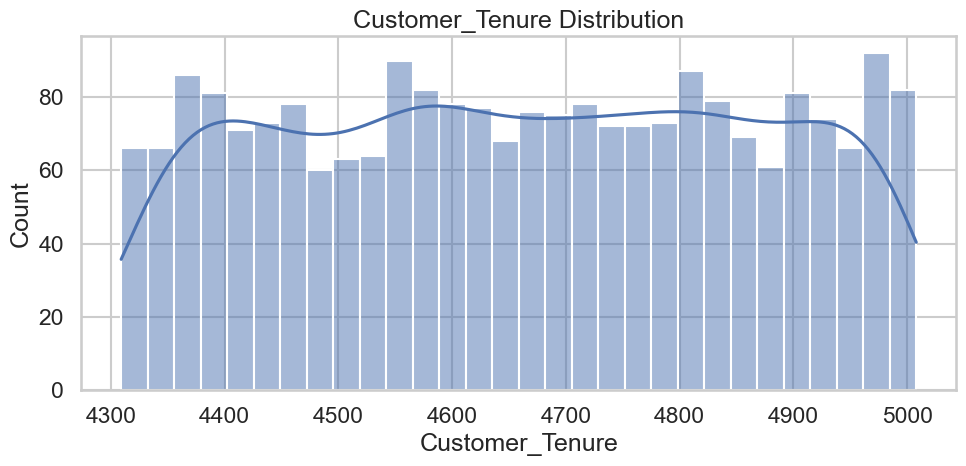

In [84]:
plot_histogram(df, "Customer_Tenure")

## Correlation Analysis

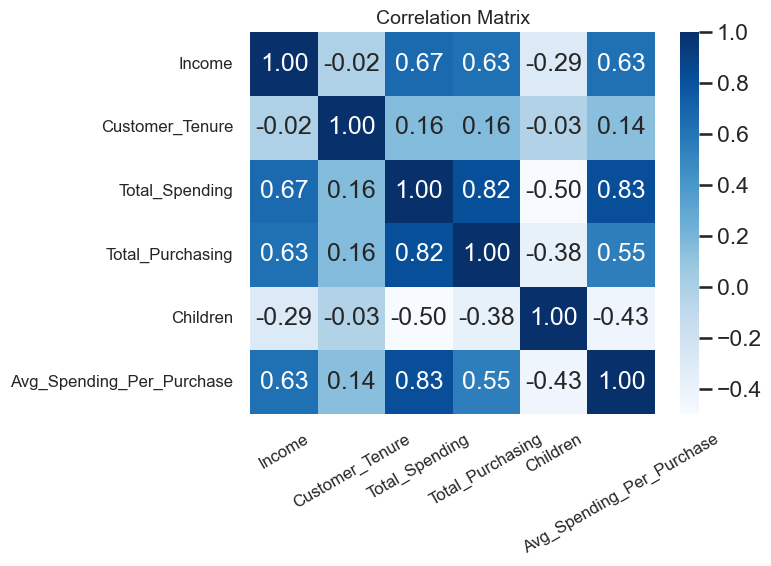

,Income,Customer_Tenure,Total_Spending,Total_Purchasing,Children,Avg_Spending_Per_Purchase
Income,1.00,-0.02,0.67,0.63,-0.29,0.63
Customer_Tenure,-0.02,1.00,0.16,0.16,-0.03,0.14
Total_Spending,0.67,0.16,1.00,0.82,-0.50,0.83
Total_Purchasing,0.63,0.16,0.82,1.00,-0.38,0.55
Children,-0.29,-0.03,-0.50,-0.38,1.00,-0.43
Avg_Spending_Per_Purchase,0.63,0.14,0.83,0.55,-0.43,1.00


In [92]:

corr_cols = [
    "Income", "Customer_Tenure", "Total_Spending",
    "Total_Purchasing", "Children", "Avg_Spending_Per_Purchase"
]

corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")

plt.title("Correlation Matrix", fontsize=14)

ax.tick_params(axis='x', labelsize=12, rotation=30)
ax.tick_params(axis='y', labelsize=12, rotation=0)

plt.tight_layout()
plt.show()

corr_matrix

## Bivariate Analysis

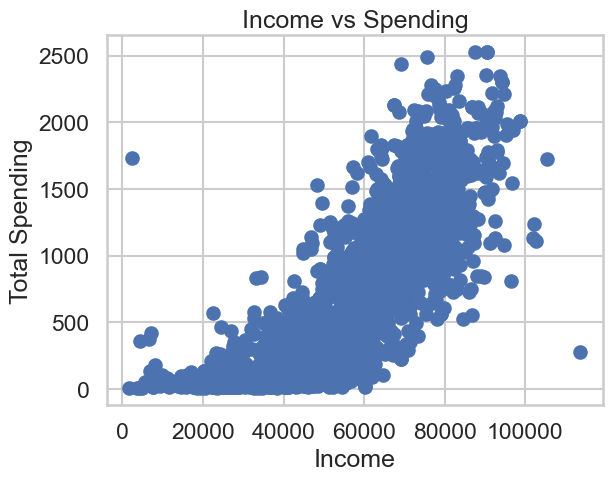

In [105]:

df_filtered = df.copy()
df_filtered = remove_iqr_outliers(df_filtered, 'Income')

plt.figure()
plt.scatter(df_filtered['Income'], df_filtered['Total_Spending'])
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.title('Income vs Spending')
plt.show()

**Insight**

Income generally shows a positive relationship with total spending, indicating that customers with higher income tend to spend more overall.

**Note**

The relationship is perfectly not linear, suggesting that other factors may also influence spending behavior.

,Children,Total_Spending
0,0,"1,106.03"
1,1,472.73
2,2,245.95
3,3,274.60


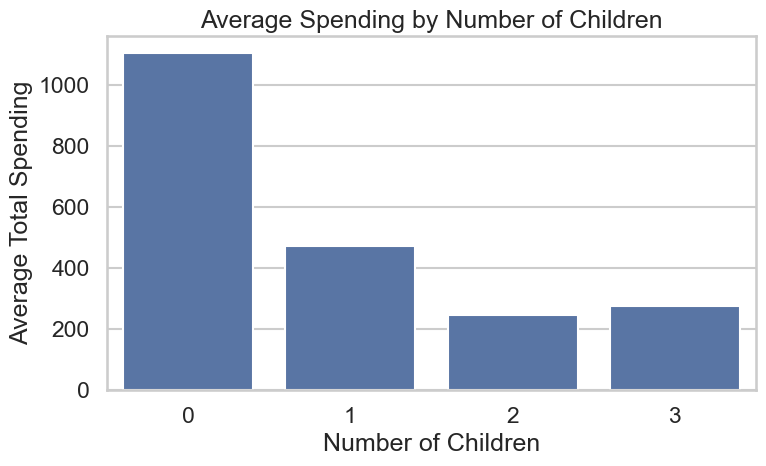

In [106]:
children_spending = (
    df.groupby("Children", as_index=False)["Total_Spending"]
      .mean()
      .sort_values("Children")
)

display(children_spending)

plt.figure(figsize=(8, 5))
sns.barplot(data=children_spending, x="Children", y="Total_Spending")
plt.title("Average Spending by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Total Spending")
plt.tight_layout()
plt.show()

**Insight**

Household influences spending behavior, with fewer dependents generally associated with higher spending.

## Customer Segmentation

In [99]:
df['Spending_Segment'] = pd.qcut(
    df['Total_Spending'], 
    q=3, 
    labels=["Low", "Mid", "High"])

df['Spending_Segment'].value_counts().sort_index()

Spending_Segment
Low     748
Mid     745
High    747
Name: count, dtype: int64

In [100]:
segment_profile = (
    df.groupby('Spending_Segment')[['Income','Total_Spending','Total_Purchasing']]
    .mean()
    .round(2)
)

display(segment_profile)

C:\Users\kim_c\AppData\Local\Temp\ipykernel_7120\3449011184.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Spending_Segment')[['Income','Total_Spending','Total_Purchasing']]


,Income,Total_Spending,Total_Purchasing
Spending_Segment,,,
Low,"32,780.12",51.22,4.70
Mid,"50,832.61",412.98,13.04
High,"73,036.97","1,353.43",19.88


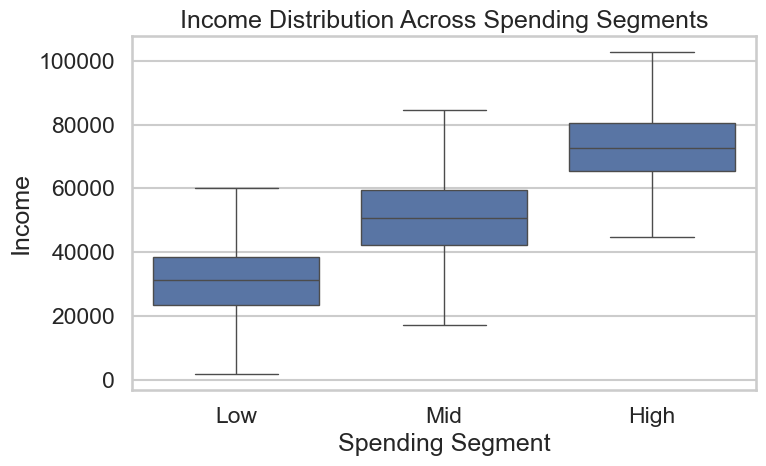

In [101]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Spending_Segment",
    y="Income",
    order=["Low", "Mid", "High"],
    showfliers=False
)
plt.title("Income Distribution Across Spending Segments")
plt.xlabel("Spending Segment")
plt.ylabel("Income")
plt.tight_layout()
plt.show()

**Insight**

High-level customers show significantly higher income and purchase frequency, suggesting a strong targeting potential.

## RFM Analysis

In [108]:
rfm = df.copy()

rfm['Frequency'] = rfm['Total_Purchasing']
rfm['Monetary'] = rfm['Total_Spending']
rfm['Recency'] = rfm['Customer_Tenure'] #Caution!

rfm[['Recency', 'Frequency', 'Monetary']].describe()


,Recency,Frequency,Monetary
count,"2,240.00","2,240.00","2,240.00"
mean,"4,662.58",12.54,605.80
std,202.12,7.21,602.25
min,"4,309.00",0.00,5.00
25%,"4,489.75",6.00,68.75
50%,"4,664.50",12.00,396.00
75%,"4,838.00",18.00,"1,045.50"
max,"5,008.00",32.00,"2,525.00"


In [112]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4])

rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm["RFM_Score"] = (rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))
rfm["RFM_Total"] = (rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1))

rfm.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Total_Purchasing,Children,Customer_Tenure,Avg_Spending_Per_Purchase,Spending_Segment,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,5524,1957,Graduation,Single,"58,138.00",0,0,2012-09-04,4972,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,1617,22,0,4972,70.30,High,22,1617,1,4,4,144,9
1,2174,1954,Graduation,Single,"46,344.00",1,1,2014-03-08,4422,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,27,4,2,4422,5.40,Low,4,27,4,1,1,411,6
2,4141,1965,Graduation,Together,"71,613.00",0,0,2013-08-21,4621,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,776,20,0,4621,36.95,Mid,20,776,3,4,3,343,10
3,6182,1984,Graduation,Together,"26,646.00",1,0,2014-02-10,4448,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,53,6,1,4448,7.57,Low,6,53,4,1,1,411,6
4,5324,1981,PhD,Married,"58,293.00",1,0,2014-01-19,4470,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,422,14,1,4470,28.13,Mid,14,422,4,3,3,433,10


In [113]:
def rfm_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    else:
        return "At Risk"
    
rfm['RFM_Segment'] = rfm['RFM_Total'].apply(rfm_segment)

rfm['RFM_Segment'].value_counts()

RFM_Segment
Loyal Customers        658
Potential Loyalists    613
Champions              486
At Risk                483
Name: count, dtype: int64

In [117]:
segment_pct = rfm['RFM_Segment'].value_counts(normalize=True) * 100
segment_pct

RFM_Segment
Loyal Customers       29.38
Potential Loyalists   27.37
Champions             21.70
At Risk               21.56
Name: proportion, dtype: float64

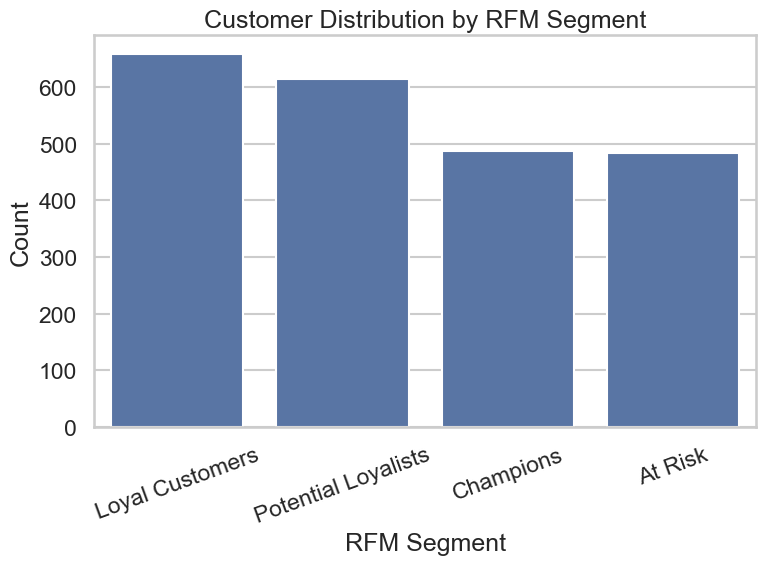

In [116]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=rfm,
    x='RFM_Segment',
    order=rfm['RFM_Segment'].value_counts().index
)
plt.title('Customer Distribution by RFM Segment')
plt.xlabel('RFM Segment')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Insight**

The customer base is in strong retention with 56.75% occupied by loyalists, however, 21.56% of At Risk customers suggests that re-engagement is important.